In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [3]:

df_filtrado = pd.read_csv("df_filtrado.csv")


In [ ]:
encoder = LabelEncoder()
df_filtrado["GRD_codificada"] = encoder.fit_transform(df_filtrado["GRD"])


In [ ]:
X = df_filtrado.drop(columns=["GRD", "GRD_codificada"])
X = pd.get_dummies(X)

y = df_filtrado["GRD_codificada"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
modelo = RandomForestClassifier(n_estimators=1, random_state=42, warm_start=True)
modelo.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1, random_state=42, warm_start=True)

In [ ]:
train_errors = []
test_errors = []

for i in range(1, 501):  #500 árboles en total
    modelo.n_estimators = i
    modelo.fit(X_train, y_train) 
    
    #Calcular el error de entrenamiento y prueba
    train_error = 1 - modelo.score(X_train, y_train)
    test_error = 1 - modelo.score(X_test, y_test)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:466: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


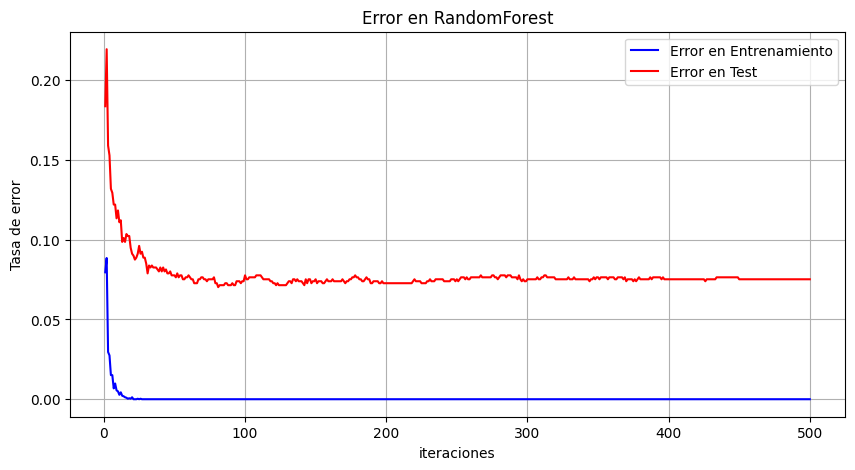

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 501), train_errors, label="Error en Entrenamiento", color='blue')
plt.plot(range(1, 501), test_errors, label="Error en Test", color='red')
plt.xlabel("iteraciones")
plt.ylabel("Tasa de error")
plt.title("Error en RandomForest")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = modelo.predict(X_test)
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Reporte de Clasificación:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.84      0.96      0.90        50
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.94      0.84      0.89        57
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       1.00      0.98      0.99        50
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.98      1.00      0.99        63
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       1.00      0.97      0.98        65
                                                                   146101 - PH CESÁREA       0.79      0.99      0.88       163
                                                              146102 - PH CES

C:\Users\Pancho\AppData\Local\Temp\ipykernel_13684\1509262034.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


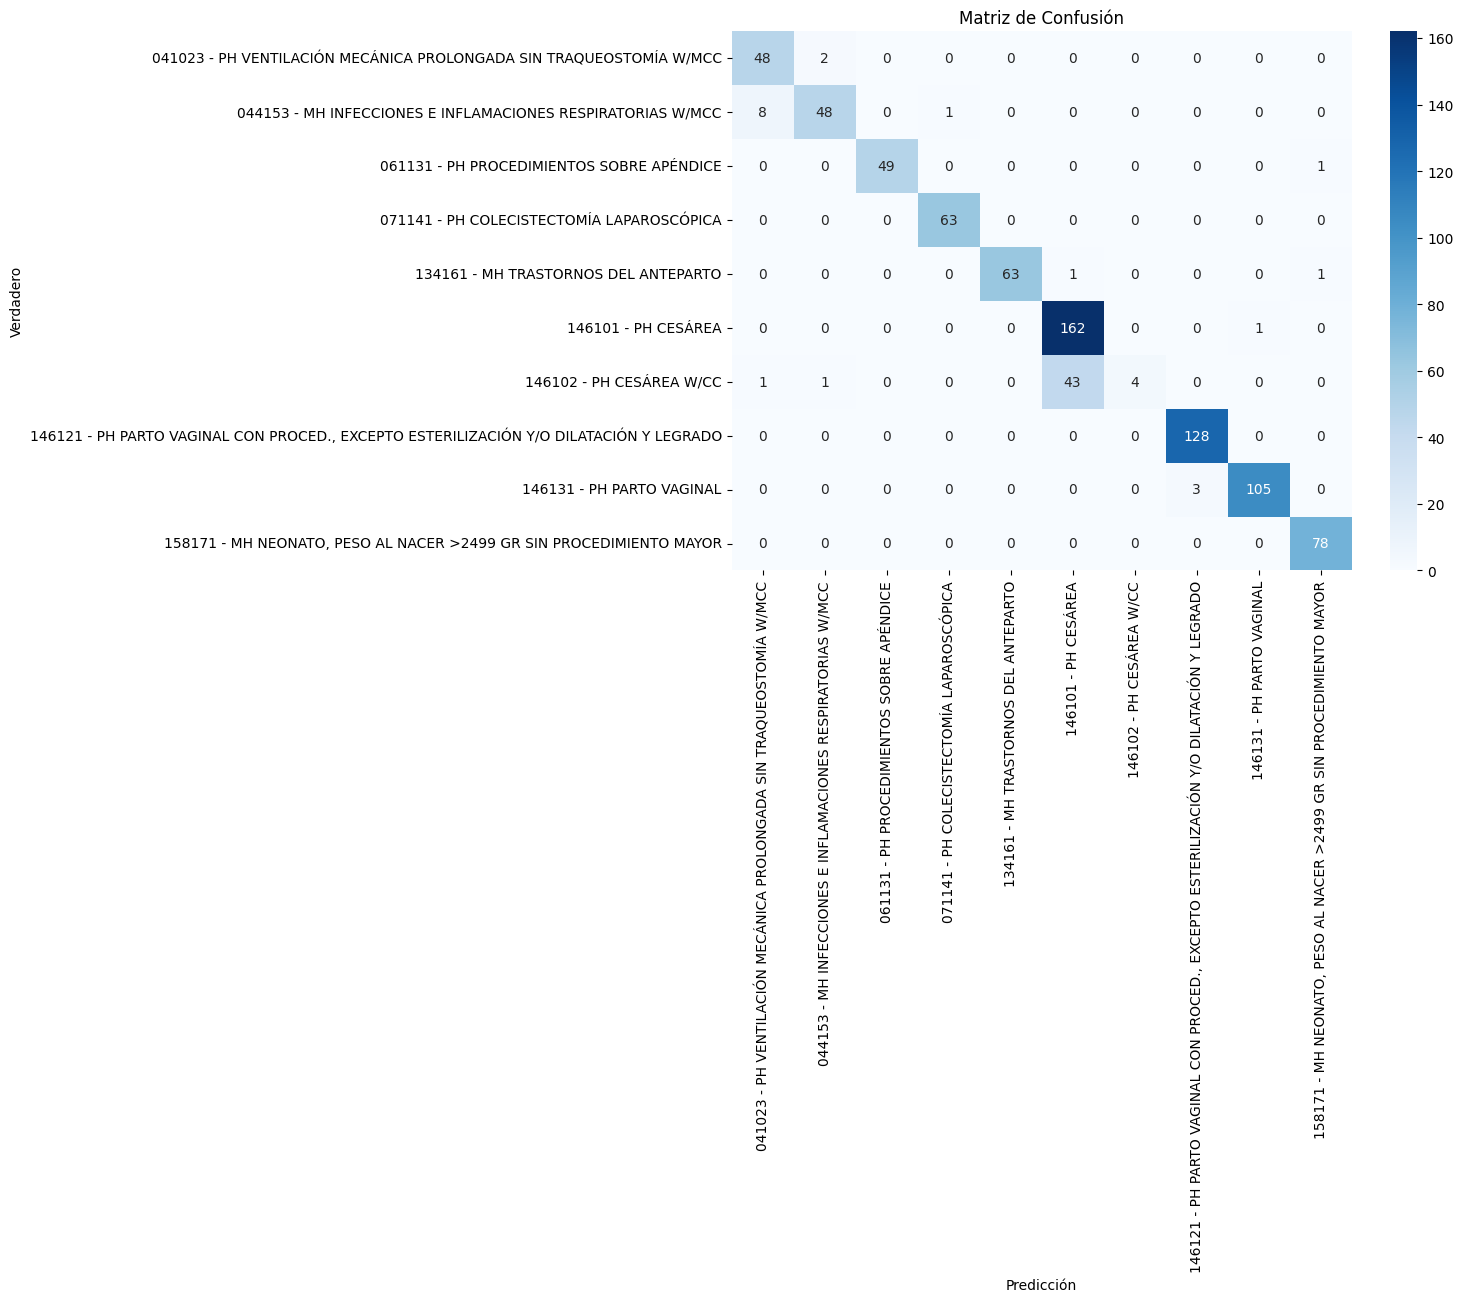

In [ ]:
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()


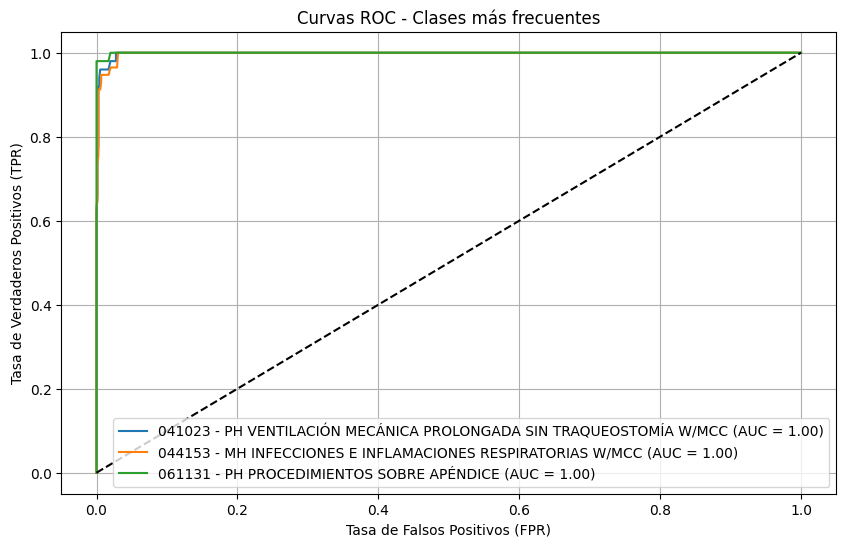

In [ ]:
y_test_bin = label_binarize(y_test, classes=range(len(encoder.classes_)))

y_score = modelo.predict_proba(X_test)

plt.figure(figsize=(10, 6))
for i in [0, 1, 2]: 
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curvas ROC - Clases más frecuentes")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()